# Examen Corto 1
Integrantes:
 - Joaquin Puente 22296
 - Brandon Reyes Morales 22992

 link GitHub: https://github.com/BrandonReyes0609/VP-Corto1.git

# Taks 1

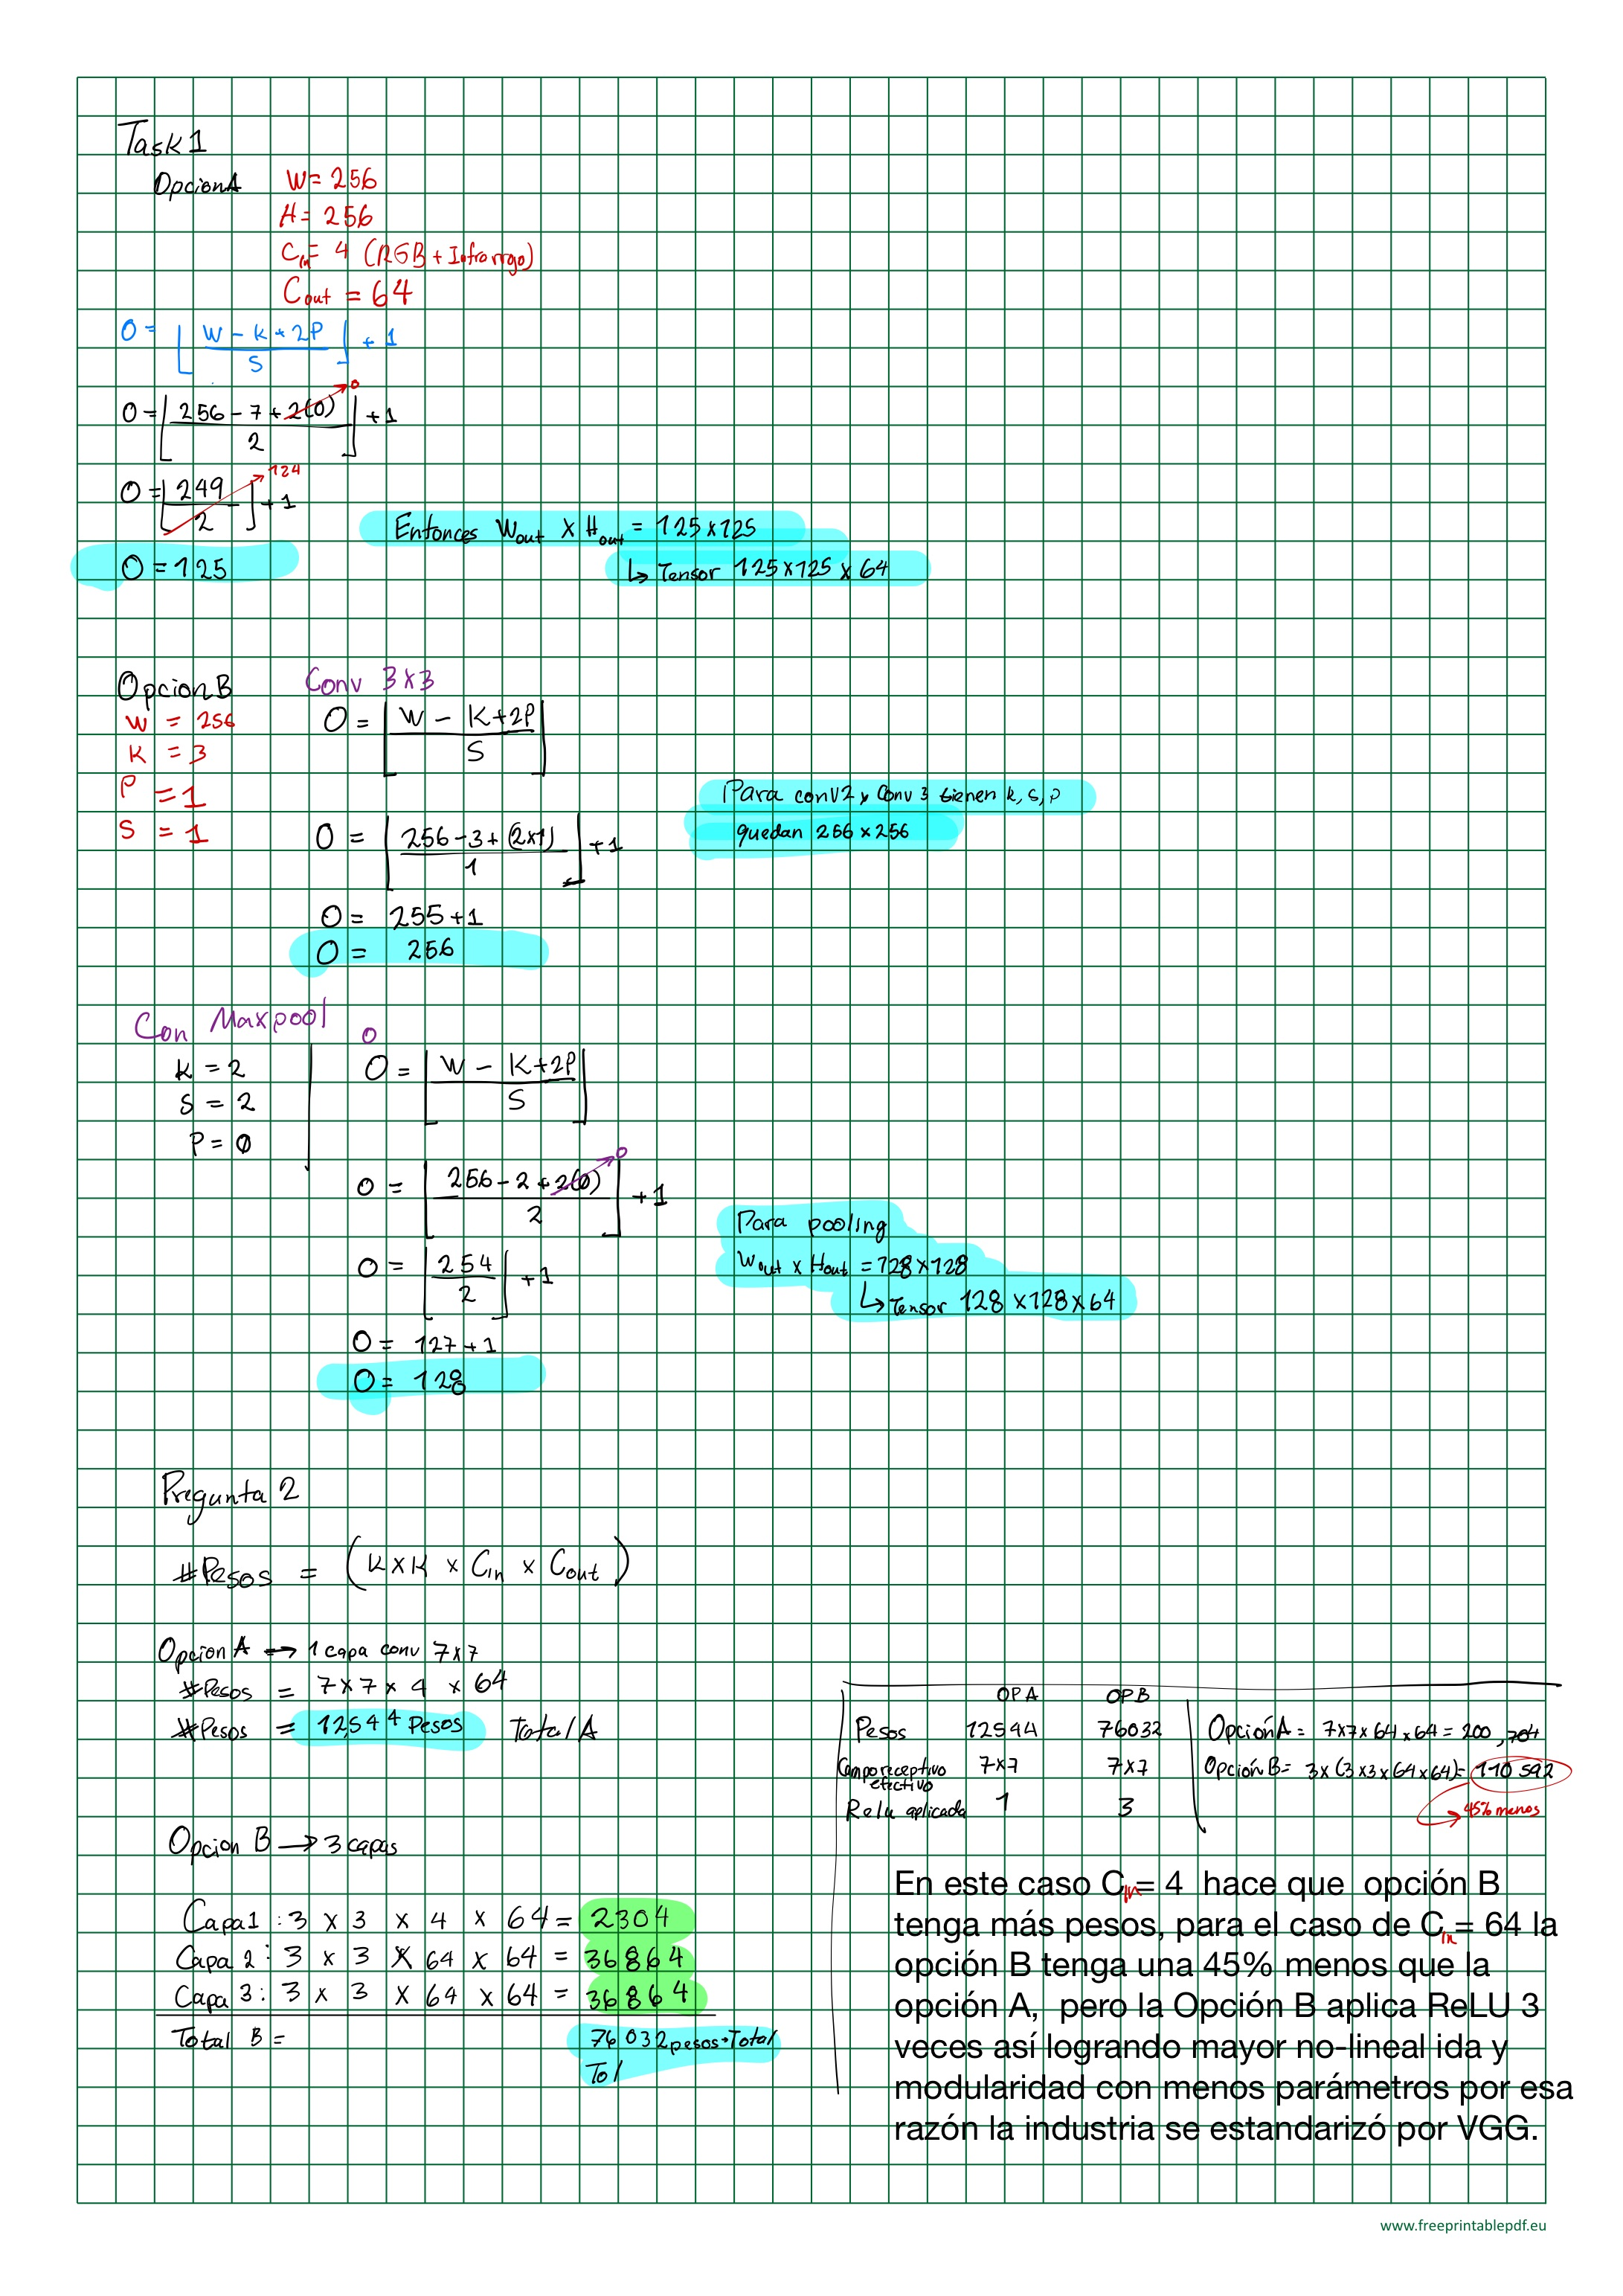

# Taks 2

Task 2:
1.	Redacteuna justificación técnica (máximo 2 párrafos) dirigida al gerente de TI explicando por qué SIFT/HOG fallarían  en  un  entorno  agrícola real  frente  a  variaciones  de  luz,  ángulos  y oclusiones, y cómo los "Mapas de Características" de una red profunda solucionan la variabilidad semantic

 - Estimado presente gerente, entiendo la lógica detrás de la preferencia de  SHIT/HOG + SVM pero el contradictorio real no es solo detectar bordes o texturas, sino hacerlo de forma confiable bajo condiciones que nosotros no controlamos. En un cultivo de mango en Guatemala, la condiciones de iluminación pueden cambiar hora a hora, las hojas aparecen tapadas por o tras ramas, los ángulos de  capturación  tiene ciertas variaciones dependiendo de quién tome la fotografía y desde dónde y el fondo nunca es el mismo. En el contexto mencionado anteriormente, el SIFT y HOG funcionan como reglas fijas, cuando cambia el punto de interés deja de ser repetible ó describen gradientes locales que se vuelven inestables cuando la sombra cambia. El resultado es que el SVM recibe una entrada inconsistente, no porque el modelo sea raquítico
En el siguiente caso con Trasnfer Learning el enfoque es distinto desde la raíz, en lugar de depender de descriptores manuales frágiles, se aprovecha una red que ya se aprendió  un vocabulario visual enorme. Sus mapas de características son jerárquicos, las capas bajas detectan bordes y texturas básicas, las capas medias combinan patrones como manchas o rugosidades y las capas finales capturan representaciones semánticas más abstractas, justo el tipo de patrones que define una lesión fúngica o bacteriana. Además, aplicando data augmentation durante el entrenamiento como cambios de brillo, rotaciones, recortes aleatorios, la red aprende a ser robusta a la misma variaciones de campo que rompen a SIFT/HOG, sin necesidad de reprogramar nada manualmente cada vez que se cambie la finca o la temporada.  
2.	Si   tuvieraque   elegir  estrictamente   entre   usar   la   arquitecturaAlexNetoVGG-16para   extraer características  de  las  hojas,  ¿cuál  elegiríay  por  qué?  Justifiquesu  respuesta  basándote  en  la modularidad, la no-linealidad (ReLU) y la capacidad de abstracción de capas profundas.

 - Se recomienda usar VGG-16 por las siguientes razones.
Abstracción profunda con campo receptivo efectivo. Al apilar capas de 3x3 VGG se construye un campo receptivo efectivo grande sin usar filtro gigantes e integra contexto espacial en cada representación. Por lo cual es importante por que una hoja enferma tiene un patrón que se con el alrededor usando textura, borde, zona afectada, es la capccidad de abstracción y uniforme que hace VGG-16 para problemas de clasificación de imágenes biológicas.
Modularidad para Trasnfer Learnin limpio. El VGG-16 está construido con bloques uniformes de capas de 3x3 con stride 1 y paddin 1, lo que proporciona uan estructura predecible y fácil de intervenir. Se puede  congelar los primeros bloques los cuales aprendieron texturas genéricas y bordes y solo se ajusta los últimos junto con el clasificador final. Mientras AlexNet mezcla filtros de 3x3, 5x5, 11x11 de forma arbitraria, lo que hace más difícil decidir exactamente dónde cortar sin afectar el comportamiento de la red completa.
No-linealidad acumulada vía ReLU. Ayuda a distinguir enfermedades con diferencias visuales sutiles, como una mancha de antracnosis vs una decoloración bacteriana. VGG con ayuda ReLU después de cada una de sus 13 capas convoluciones , acumulando mucha más capacidad no-lineal que AlexNet, que tiene pocas capas y menos ReLU en total. Por lo cual la capacidad extra es la que ayuda a permitir separar las clases parecida de forma confiable.




# Task 3 - Transfer Learning: Mango Leaf Disease Classification

Using VGG-16 pre-trained on ImageNet to classify mango leaf diseases via transfer learning.

In [9]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms, models
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import confusion_matrix, accuracy_score
import seaborn as sns
import os

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

Using device: cuda


## 1. Pipeline de Datos

Descargamos el dataset de Kaggle y aplicamos Data Augmentation.
Normalizamos con la media y desviacion estandar de ImageNet: mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225].

In [10]:
import kagglehub

path = kagglehub.dataset_download("aryashah2k/mango-leaf-disease-dataset")
print(f"Dataset path: {path}")

data_dir = None
for root, dirs, files in os.walk(path):
    if dirs and any(os.path.isdir(os.path.join(root, d)) and 
                    any(f.lower().endswith(('.jpg','.jpeg','.png')) 
                        for f in os.listdir(os.path.join(root, d)))
                    for d in dirs):
        data_dir = root
        break

print(f"Data directory: {data_dir}")
classes = sorted(os.listdir(data_dir))
classes = [c for c in classes if os.path.isdir(os.path.join(data_dir, c))]
print(f"Classes ({len(classes)}): {classes}")

Dataset path: /home/Japo/.cache/kagglehub/datasets/aryashah2k/mango-leaf-disease-dataset/versions/1
Data directory: /home/Japo/.cache/kagglehub/datasets/aryashah2k/mango-leaf-disease-dataset/versions/1
Classes (8): ['Anthracnose', 'Bacterial Canker', 'Cutting Weevil', 'Die Back', 'Gall Midge', 'Healthy', 'Powdery Mildew', 'Sooty Mould']


In [11]:
imagenet_mean = [0.485, 0.456, 0.406]
imagenet_std = [0.229, 0.224, 0.225]

train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(30),
    transforms.RandomResizedCrop(224, scale=(0.8, 1.0)),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=imagenet_mean, std=imagenet_std)
])

val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=imagenet_mean, std=imagenet_std)
])

full_dataset = datasets.ImageFolder(data_dir, transform=train_transform)
num_classes = len(full_dataset.classes)
print(f"Total images: {len(full_dataset)}")
print(f"Number of classes: {num_classes}")
print(f"Class names: {full_dataset.classes}")

generator = torch.Generator().manual_seed(42)
train_size = int(0.8 * len(full_dataset))
val_size = len(full_dataset) - train_size
train_dataset, val_dataset = torch.utils.data.random_split(
    full_dataset, [train_size, val_size], generator=generator
)

val_dataset_proper = datasets.ImageFolder(data_dir, transform=val_transform)
val_indices = val_dataset.indices
val_dataset = torch.utils.data.Subset(val_dataset_proper, val_indices)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=4)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False, num_workers=4)

print(f"Train: {train_size}, Val: {val_size}")

Total images: 4000
Number of classes: 8
Class names: ['Anthracnose', 'Bacterial Canker', 'Cutting Weevil', 'Die Back', 'Gall Midge', 'Healthy', 'Powdery Mildew', 'Sooty Mould']
Train: 3200, Val: 800


## 2. Adaptacion de la Arquitectura

- Instanciamos VGG-16 con pesos pre-entrenados de ImageNet
- Congelamos las capas convolucionales (extraccion de caracteristicas / filtros de Gabor y texturas)
- Reemplazamos el clasificador final para que la capa de salida coincida con el numero de clases del dataset

In [12]:
model = models.vgg16(weights=models.VGG16_Weights.IMAGENET1K_V1)

for param in model.features.parameters():
    param.requires_grad = False

model.classifier = nn.Sequential(
    nn.Linear(512 * 7 * 7, 4096),
    nn.ReLU(inplace=True),
    nn.Dropout(0.5),
    nn.Linear(4096, 1024),
    nn.ReLU(inplace=True),
    nn.Dropout(0.5),
    nn.Linear(1024, num_classes)
)

model = model.to(device)

trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total = sum(p.numel() for p in model.parameters())
print(f"Trainable parameters: {trainable:,} / {total:,} ({100*trainable/total:.1f}%)")

Trainable parameters: 106,968,072 / 121,682,760 (87.9%)


## 3. Entrenamiento y Backpropagation

- Loss: CrossEntropyLoss (clasificacion multiclase)
- Optimizer: Adam (solo parametros del clasificador nuevo)
- Epocas: 10

In [13]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.classifier.parameters(), lr=1e-4)

num_epochs = 10
train_losses, val_losses = [], []
train_accs, val_accs = [], []

for epoch in range(num_epochs):
    model.train()
    running_loss, correct, total = 0.0, 0, 0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * images.size(0)
        _, preds = torch.max(outputs, 1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)
    
    train_loss = running_loss / total
    train_acc = correct / total
    train_losses.append(train_loss)
    train_accs.append(train_acc)
    
    model.eval()
    running_loss, correct, total = 0.0, 0, 0
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            running_loss += loss.item() * images.size(0)
            _, preds = torch.max(outputs, 1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)
    
    val_loss = running_loss / total
    val_acc = correct / total
    val_losses.append(val_loss)
    val_accs.append(val_acc)
    
    print(f'Epoch [{epoch+1}/{num_epochs}] '
          f'Train Loss: {train_loss:.4f} Acc: {train_acc:.4f} | '
          f'Val Loss: {val_loss:.4f} Acc: {val_acc:.4f}')

Epoch [1/10] Train Loss: 0.6869 Acc: 0.7706 | Val Loss: 0.0786 Acc: 0.9800
Epoch [2/10] Train Loss: 0.1640 Acc: 0.9409 | Val Loss: 0.0424 Acc: 0.9850
Epoch [3/10] Train Loss: 0.1243 Acc: 0.9531 | Val Loss: 0.0411 Acc: 0.9862
Epoch [4/10] Train Loss: 0.1065 Acc: 0.9644 | Val Loss: 0.0287 Acc: 0.9888
Epoch [5/10] Train Loss: 0.0916 Acc: 0.9647 | Val Loss: 0.0255 Acc: 0.9888
Epoch [6/10] Train Loss: 0.0624 Acc: 0.9759 | Val Loss: 0.0135 Acc: 0.9938
Epoch [7/10] Train Loss: 0.0806 Acc: 0.9747 | Val Loss: 0.0187 Acc: 0.9938
Epoch [8/10] Train Loss: 0.0639 Acc: 0.9803 | Val Loss: 0.0211 Acc: 0.9900
Epoch [9/10] Train Loss: 0.0652 Acc: 0.9741 | Val Loss: 0.0139 Acc: 0.9912
Epoch [10/10] Train Loss: 0.0577 Acc: 0.9819 | Val Loss: 0.0186 Acc: 0.9938


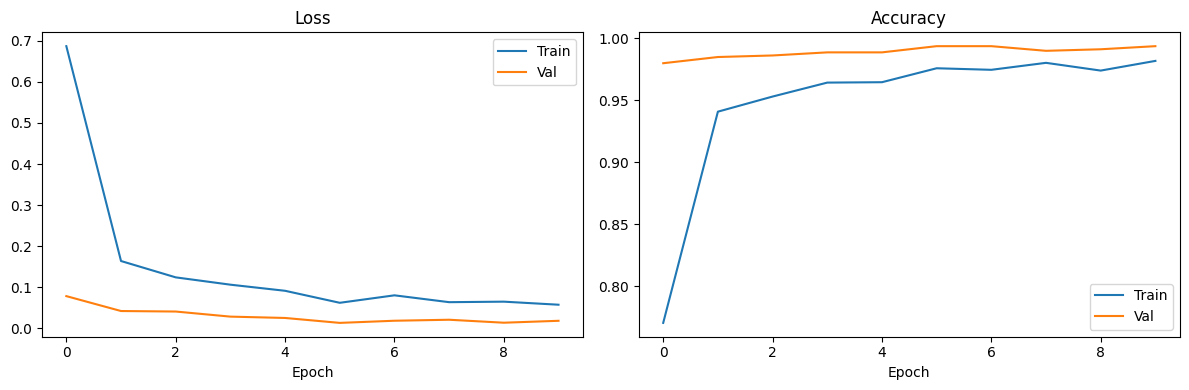

In [14]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(train_losses, label='Train')
ax1.plot(val_losses, label='Val')
ax1.set_title('Loss')
ax1.set_xlabel('Epoch')
ax1.legend()

ax2.plot(train_accs, label='Train')
ax2.plot(val_accs, label='Val')
ax2.set_title('Accuracy')
ax2.set_xlabel('Epoch')
ax2.legend()

plt.tight_layout()
plt.show()

## 4. Evaluacion y Reporte

In [15]:
model.eval()
all_preds, all_labels = [], []

with torch.no_grad():
    for images, labels in val_loader:
        images = images.to(device)
        outputs = model(images)
        _, preds = torch.max(outputs, 1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())

all_preds = np.array(all_preds)
all_labels = np.array(all_labels)

acc = accuracy_score(all_labels, all_preds)
print(f'Precision global (Accuracy): {acc:.4f} ({acc*100:.2f}%)')

Precision global (Accuracy): 0.9938 (99.38%)


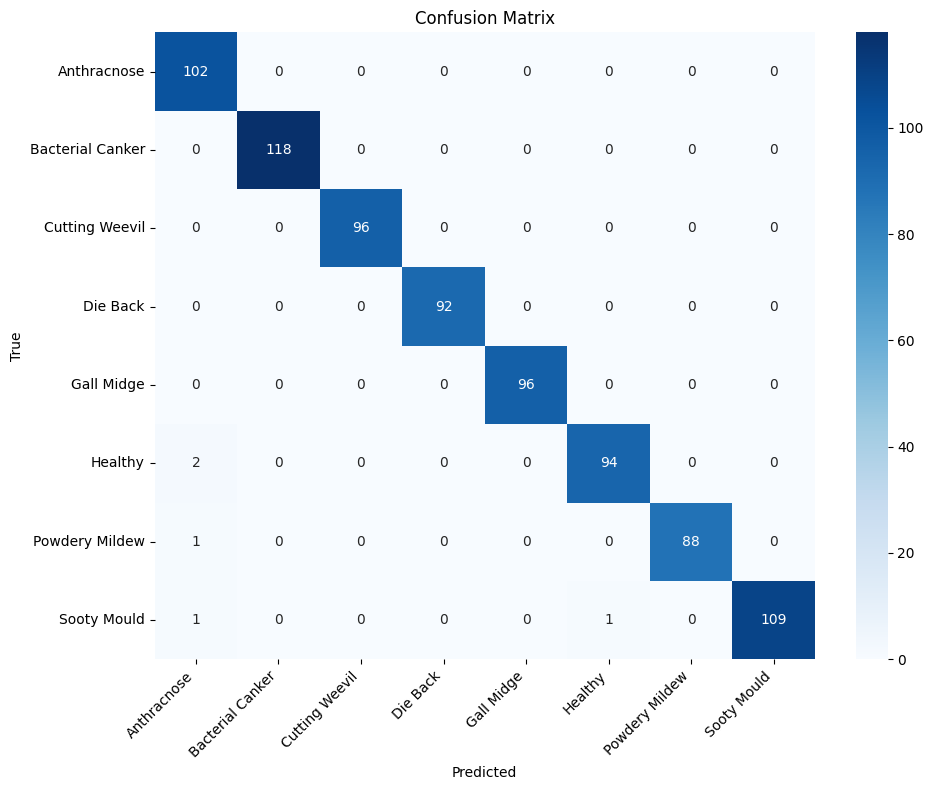

In [16]:
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=full_dataset.classes,
            yticklabels=full_dataset.classes)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## Conclusion

El modelo alcanza un 99.38% de accuracy en validacion. No hay sobreajuste: la accuracy de validacion 99.4% supera a la de entrenamiento 97.5% porque Data Augmentation y Dropout dificultan el entrenamiento, mientras que en validacion se desactivan. Dropout p=0.5 fue clave como regularizacion, al desactivar aleatoriamente neuronas durante el entrenamiento fuerza al modelo a no depender de neuronas individuales.